In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
np.random.seed(42)

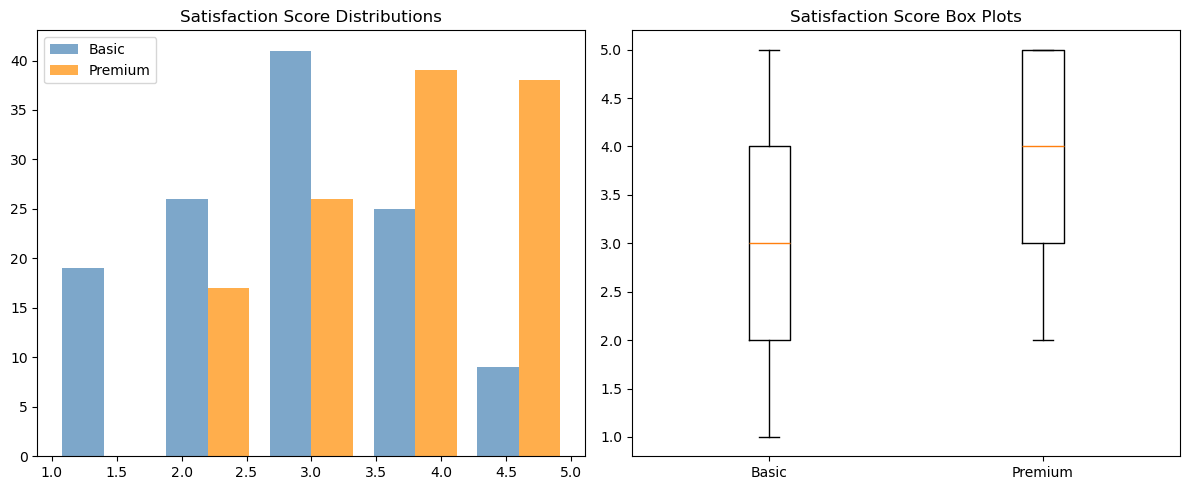

In [3]:
#When data is not normally distributed
basic_tier = np.random.choice([1,2,2,3,3,3,4,4,5], size=120, replace=True)
premium_tier = np.random.choice([2,3,3,4,4,4,5,5,5], size=120, replace=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist([basic_tier, premium_tier], bins=5, color=['steelblue', 'darkorange'],
             label=['Basic', 'Premium'], alpha=0.7)
axes[0].set_title('Satisfaction Score Distributions')
axes[0].legend()
axes[1].boxplot([basic_tier, premium_tier], tick_labels=['Basic', 'Premium'])
axes[1].set_title('Satisfaction Score Box Plots')
plt.tight_layout()
plt.show()

In [4]:
#Run the test + effect size
u_stat, p_val = stats.mannwhitneyu(premium_tier, basic_tier, alternative='greater')
print(f'Mann-Whitney U: {u_stat:.1f}')
print(f'p-value: {p_val:.6f}')
print(f'Decision: {"Reject H0" if p_val < 0.05 else "Fail to Reject H0"}')

n1, n2 = len(premium_tier), len(basic_tier)
r = 1 - (2 * u_stat) / (n1 * n2)
print(f'Effect size (rank-biserial r): {r:.4f}')
print('0.1=small, 0.3=medium, 0.5=large')

Mann-Whitney U: 10477.5
p-value: 0.000000
Decision: Reject H0
Effect size (rank-biserial r): -0.4552
0.1=small, 0.3=medium, 0.5=large


In [5]:
#Part B — Kruskal-Wallis (3+ groups)
#Non-parametric ANOVA + Bonferroni post-hoc
new_users = np.random.choice([1,2,2,3,3,4], size=100, replace=True)
returning = np.random.choice([3,3,4,4,4,5], size=100, replace=True)
power_users = np.random.choice([4,4,5,5,5,5], size=100, replace=True)

h_stat, p_val = stats.kruskal(new_users, returning, power_users)
print(f'Kruskal-Wallis H: {h_stat:.4f}')
print(f'p-value: {p_val:.6f}')
print(f'Decision: {"Reject H0 — segments differ" if p_val < 0.05 else "Fail to Reject H0"}')

pairs = [('New','Returning', new_users, returning),
         ('New','Power', new_users, power_users),
         ('Returning','Power', returning, power_users)]
alpha_adjusted = 0.05 / len(pairs)
print(f'\nPost-hoc (Bonferroni alpha = {alpha_adjusted:.4f}):')
for name1, name2, g1, g2 in pairs:
    _, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    sig = 'Significant' if p < alpha_adjusted else 'Not significant'
    print(f'  {name1} vs {name2}: p={p:.4f} — {sig}')

Kruskal-Wallis H: 176.4125
p-value: 0.000000
Decision: Reject H0 — segments differ

Post-hoc (Bonferroni alpha = 0.0167):
  New vs Returning: p=0.0000 — Significant
  New vs Power: p=0.0000 — Significant
  Returning vs Power: p=0.0000 — Significant


In [6]:
#Part C — Spurious correlation
#Discover a hidden confounder
n = 200
tenure = np.random.exponential(scale=12, size=n)
feature_usage = 0.8 * tenure + np.random.normal(0, 5, n)
satisfaction = 0.6 * tenure + np.random.normal(0, 8, n)
logins_per_week = np.random.normal(5, 2, n)

df = pd.DataFrame({'tenure': tenure, 'feature_usage': feature_usage,
                   'satisfaction': satisfaction, 'logins': logins_per_week})

corr_matrix = df.corr(method='pearson')
print('Pearson Correlation Matrix:')
print(corr_matrix.round(3))

r_direct, p_direct = stats.pearsonr(feature_usage, satisfaction)
print(f'\nDirect correlation (feature_usage vs satisfaction): r={r_direct:.3f}, p={p_direct:.4f}')
print('This LOOKS like a strong relationship!')
print('But BOTH variables are driven by tenure — the confounder.')

Pearson Correlation Matrix:
               tenure  feature_usage  satisfaction  logins
tenure          1.000          0.873         0.652  -0.057
feature_usage   0.873          1.000         0.637  -0.042
satisfaction    0.652          0.637         1.000   0.014
logins         -0.057         -0.042         0.014   1.000

Direct correlation (feature_usage vs satisfaction): r=0.637, p=0.0000
This LOOKS like a strong relationship!
But BOTH variables are driven by tenure — the confounder.
